# Intent–Behavior Deviation in Smart Contracts
## Notebook 1: Tier 1 — Classical Machine Learning
**Models:** Logistic Regression · Random Forest · SVM · XGBoost  
**Features:** Hybrid (398-d: emb_000–emb_383 + 14 behavior flags)  
**Label:** `target` (0=safe, 1=rugpull)  
**Eval:** 5-fold Stratified CV · Full + Balanced datasets

> **Run Notebook 0 first** to generate `dataset_full.csv`, `dataset_balanced.csv`, `col_info.json`.  
> If those files don't exist, this notebook loads from `CSV_PATH` directly.

In [1]:
import io, requests

# ─────────────────────────────────────────────────────────────────────────────
# Load dataset directly from GitHub (raw CSV)
# ─────────────────────────────────────────────────────────────────────────────
GITHUB_RAW_URL = (
    'https://raw.githubusercontent.com/AbrarBb/Intent-Behavior-Deviation-Dataset'
    '/main/ml_dataset_verified_full.csv'
)

print('Downloading dataset from GitHub...')
response = requests.get(GITHUB_RAW_URL)
response.raise_for_status()
CSV_PATH = io.StringIO(response.text)
print('✅ Dataset loaded successfully from GitHub')

✅ Dataset loaded successfully from GitHub


In [2]:
!pip install -q xgboost

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, json, time, warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from xgboost                 import XGBClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics         import (f1_score, roc_auc_score, roc_curve,
                                      confusion_matrix, classification_report)

plt.rcParams['figure.dpi'] = 120
COLORS = ['#2eafcc','#f593e4']
MODEL_COLORS = ['#3498db','#d98f4e','#cd7eed','#4ddbbf']
SEED = 42;  np.random.seed(SEED)
print('Imports OK')

Imports OK


In [4]:
# ── Load data (from NB0 outputs or raw CSV) ───────────────────────────────────
import os
try:
    assert os.path.exists('dataset_full.csv')
    df_full = pd.read_csv('dataset_full.csv')
    df_bal  = pd.read_csv('dataset_balanced.csv')
    with open('col_info.json') as f: col_info = json.load(f)
    HYBRID_COLS = col_info['hybrid_cols']
    LABEL_COL   = col_info['label_col']
    print('Loaded from Notebook 0 outputs')
except:
    df_full = pd.read_csv(CSV_PATH)
    EMB_COLS    = [c for c in df_full.columns if c.startswith('emb_')]
    BEHAV_COLS  = ['owner_withdraw','emergency_withdraw','unrestricted_mint',
                   'regex_owner_withdraw','regex_emergency_withdraw','regex_unrestricted_mint',
                   'slither_ok','slither_high_count','slither_arbitrary_send',
                   'slither_suicidal','slither_unchecked_lowlevel',
                   'slither_controlled_delegatecall','slither_delegatecall_loop',
                   'slither_ownerish_any']
    HYBRID_COLS = EMB_COLS + BEHAV_COLS
    LABEL_COL   = 'target'
    min_c = df_full[LABEL_COL].value_counts().min()
    df_bal = pd.concat([
        df_full[df_full[LABEL_COL]==0].sample(min_c, random_state=SEED),
        df_full[df_full[LABEL_COL]==1].sample(min_c, random_state=SEED)
    ]).reset_index(drop=True)
    print('Loaded from raw CSV')

X_full = df_full[HYBRID_COLS].values;  y_full = df_full[LABEL_COL].values
X_bal  = df_bal[HYBRID_COLS].values;   y_bal  = df_bal[LABEL_COL].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f'Full: {X_full.shape} | Balanced: {X_bal.shape} | Features: {len(HYBRID_COLS)}')

Loaded from raw CSV
Full: (3324, 398) | Balanced: (2044, 398) | Features: 398


---
## Model Definitions

In [5]:
models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                    C=1.0, solver='lbfgs', random_state=SEED))]),
    'Random Forest': Pipeline([('sc','passthrough'),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        random_state=SEED, n_jobs=-1))]),
    'SVM': Pipeline([('sc', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                    probability=True, random_state=SEED))]),
    'XGBoost': Pipeline([('sc','passthrough'),
        ('clf', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=SEED, n_jobs=-1))])
}
MODEL_NAMES = list(models.keys())
print('Models:', MODEL_NAMES)

Models: ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost']


---
## 5-Fold CV — Full & Balanced

In [6]:
scoring = ['f1_macro','f1_weighted','roc_auc','precision_macro','recall_macro']
results_full, results_bal = {}, {}

for name, model in models.items():
    print(f'[FULL]     {name}...', end=' ', flush=True)
    t0 = time.time()
    results_full[name] = cross_validate(model, X_full, y_full, cv=cv,
                                         scoring=scoring, return_train_score=True, n_jobs=-1)
    print(f'F1={results_full[name]["test_f1_macro"].mean():.4f} ({time.time()-t0:.1f}s)')

for name, model in models.items():
    print(f'[BALANCED] {name}...', end=' ', flush=True)
    t0 = time.time()
    results_bal[name]  = cross_validate(model, X_bal, y_bal, cv=cv,
                                         scoring=scoring, return_train_score=True, n_jobs=-1)
    print(f'F1={results_bal[name]["test_f1_macro"].mean():.4f} ({time.time()-t0:.1f}s)')

[FULL]     Logistic Regression... F1=0.9676 (2.6s)
[FULL]     Random Forest... F1=0.9745 (13.0s)
[FULL]     SVM... F1=0.9698 (6.3s)
[FULL]     XGBoost... 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

F1=0.9742 (9.7s)
[BALANCED] Logistic Regression... F1=0.9667 (0.3s)
[BALANCED] Random Forest... F1=0.9701 (7.4s)
[BALANCED] SVM... F1=0.9682 (2.9s)
[BALANCED] XGBoost... 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

F1=0.9677 (5.3s)


---
## Results Tables

In [7]:
def build_table(res, label):
    rows=[]
    for name,r in res.items():
        rows.append({'Model':name,'Dataset':label,
                     'F1 Macro':   f"{r['test_f1_macro'].mean():.4f} ± {r['test_f1_macro'].std():.4f}",
                     'F1 Weighted':f"{r['test_f1_weighted'].mean():.4f}",
                     'ROC-AUC':    f"{r['test_roc_auc'].mean():.4f} ± {r['test_roc_auc'].std():.4f}",
                     'Precision':  f"{r['test_precision_macro'].mean():.4f}",
                     'Recall':     f"{r['test_recall_macro'].mean():.4f}"})
    return pd.DataFrame(rows)

df_t1_full = build_table(results_full,'Full')
df_t1_bal  = build_table(results_bal, 'Balanced')
print('=== FULL ===');   print(df_t1_full.to_string(index=False))
print('\n=== BALANCED ==='); print(df_t1_bal.to_string(index=False))
pd.concat([df_t1_full,df_t1_bal]).to_csv('tier1_results.csv',index=False)

=== FULL ===
              Model Dataset        F1 Macro F1 Weighted         ROC-AUC Precision Recall
Logistic Regression    Full 0.9676 ± 0.0087      0.9724 0.9877 ± 0.0052    0.9668 0.9686
      Random Forest    Full 0.9745 ± 0.0041      0.9785 0.9961 ± 0.0029    0.9829 0.9672
                SVM    Full 0.9698 ± 0.0045      0.9744 0.9955 ± 0.0033    0.9731 0.9668
            XGBoost    Full 0.9742 ± 0.0045      0.9782 0.9960 ± 0.0027    0.9806 0.9686

=== BALANCED ===
              Model  Dataset        F1 Macro F1 Weighted         ROC-AUC Precision Recall
Logistic Regression Balanced 0.9667 ± 0.0100      0.9667 0.9928 ± 0.0042    0.9669 0.9667
      Random Forest Balanced 0.9701 ± 0.0083      0.9701 0.9956 ± 0.0034    0.9717 0.9701
                SVM Balanced 0.9682 ± 0.0088      0.9682 0.9950 ± 0.0041    0.9688 0.9682
            XGBoost Balanced 0.9677 ± 0.0119      0.9677 0.9957 ± 0.0028    0.9684 0.9677


---
## Visualizations

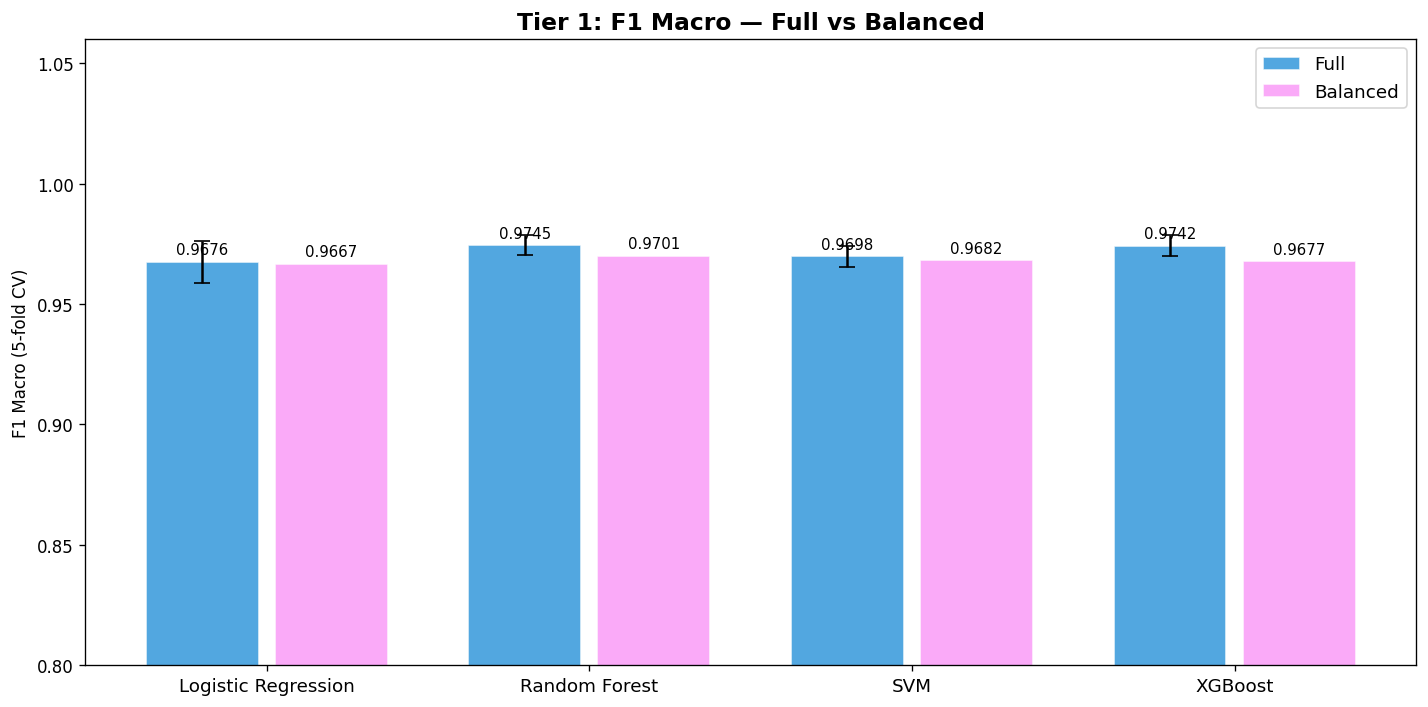

In [8]:
# VIZ 1: F1 Macro bar chart — Full vs Balanced
f1_f   = [results_full[m]['test_f1_macro'].mean() for m in MODEL_NAMES]
f1_b   = [results_bal[m]['test_f1_macro'].mean()  for m in MODEL_NAMES]
f1_std = [results_full[m]['test_f1_macro'].std()  for m in MODEL_NAMES]
x = np.arange(len(MODEL_NAMES))
fig, ax = plt.subplots(figsize=(12,6))
b1=ax.bar(x-0.2,f1_f,0.35,label='Full',    color='#3498db',yerr=f1_std,capsize=5,edgecolor='white',alpha=0.85)
b2=ax.bar(x+0.2,f1_b,0.35,label='Balanced',color='#fa9bf7',edgecolor='white',alpha=0.85)
for bar,v in zip(b1,f1_f): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.4f}',ha='center',fontsize=9)
for bar,v in zip(b2,f1_b): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.4f}',ha='center',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES,fontsize=11)
ax.set_ylabel('F1 Macro (5-fold CV)'); ax.set_ylim(0.8,1.06)
ax.set_title('Tier 1: F1 Macro — Full vs Balanced',fontsize=14,fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('t1_plot_01_f1.png',bbox_inches='tight'); plt.show()

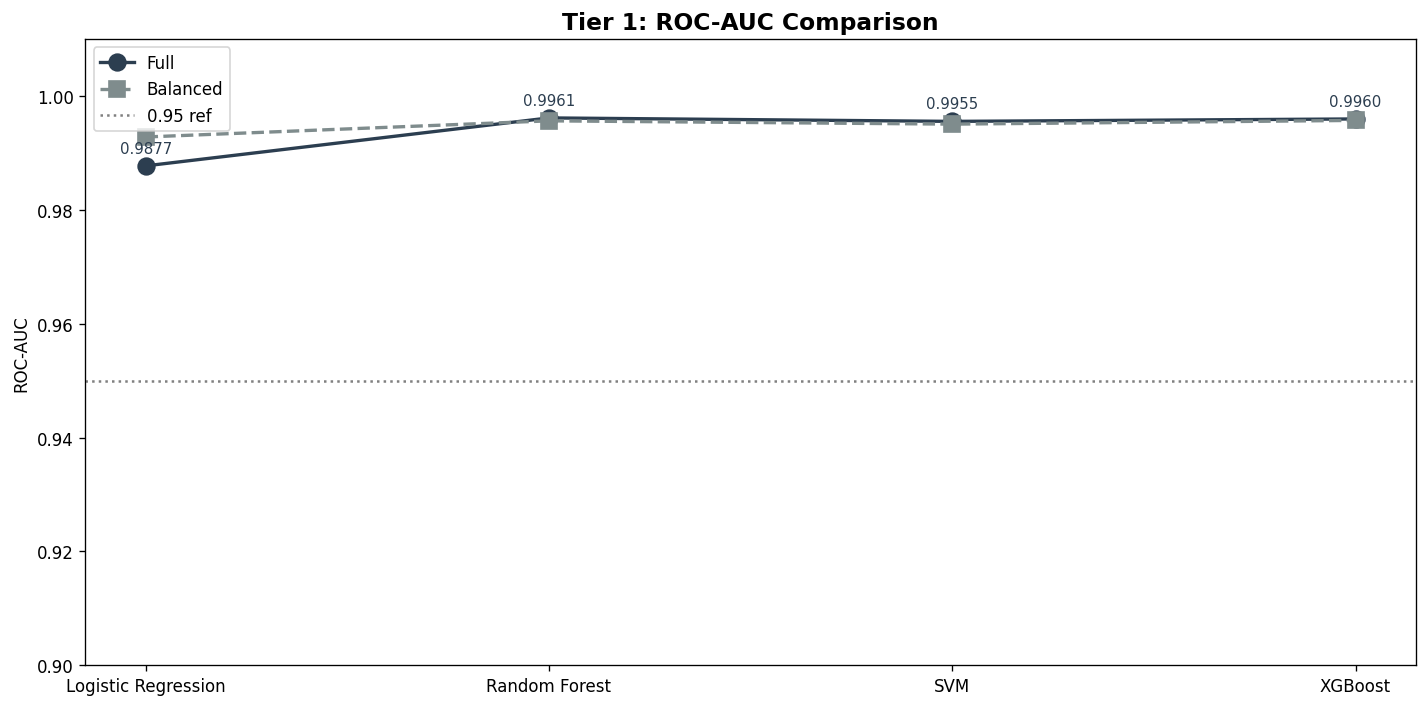

In [9]:
# VIZ 2: ROC-AUC line chart
auc_f=[results_full[m]['test_roc_auc'].mean() for m in MODEL_NAMES]
auc_b=[results_bal[m]['test_roc_auc'].mean()  for m in MODEL_NAMES]
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(MODEL_NAMES,auc_f,'o-',lw=2,ms=10,color='#2c3e50',label='Full')
ax.plot(MODEL_NAMES,auc_b,'s--',lw=2,ms=10,color='#7f8c8d',label='Balanced')
for i,(f,b) in enumerate(zip(auc_f,auc_b)):
    ax.annotate(f'{f:.4f}',(i,f),xytext=(0,8),textcoords='offset points',ha='center',fontsize=9,color='#2c3e50')
ax.axhline(0.95,color='gray',linestyle=':',label='0.95 ref')
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.9,1.01)
ax.set_title('Tier 1: ROC-AUC Comparison',fontsize=14,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('t1_plot_02_auc.png',bbox_inches='tight'); plt.show()

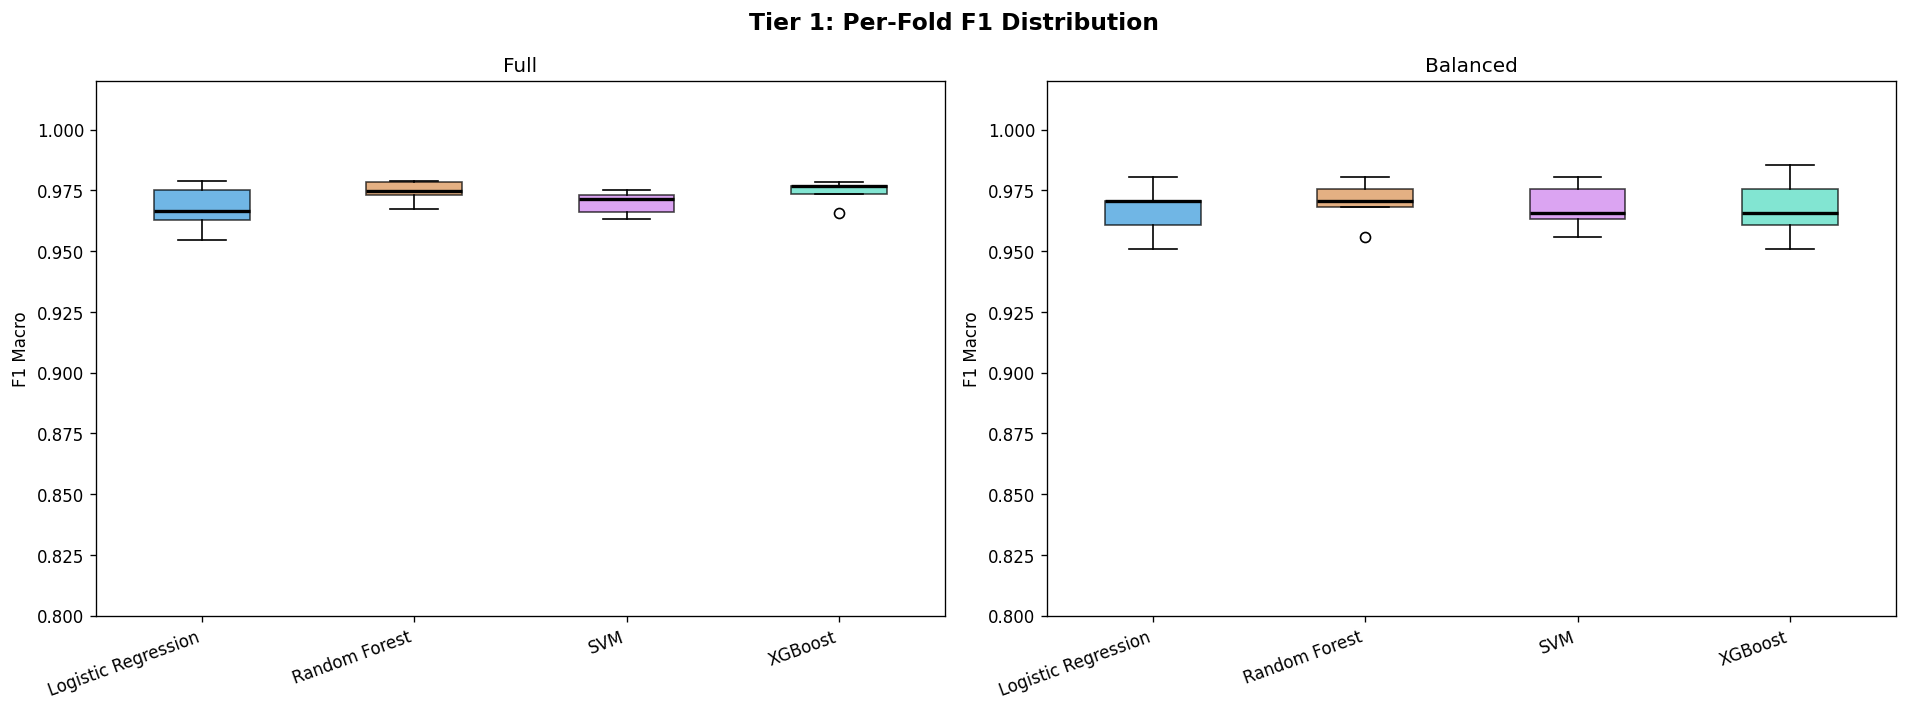

In [10]:
# VIZ 3: Boxplot of fold scores
fig, axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Tier 1: Per-Fold F1 Distribution',fontsize=14,fontweight='bold')
for ax,res,title in [(axes[0],results_full,'Full'),(axes[1],results_bal,'Balanced')]:
    data_box=[res[m]['test_f1_macro'] for m in MODEL_NAMES]
    bp=ax.boxplot(data_box,patch_artist=True,notch=False,medianprops=dict(color='black',linewidth=2))
    for patch,color in zip(bp['boxes'],MODEL_COLORS): patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(MODEL_NAMES,rotation=20,ha='right'); ax.set_ylabel('F1 Macro')
    ax.set_title(title); ax.set_ylim(0.8,1.02)
plt.tight_layout()
plt.savefig('t1_plot_03_boxplot.png',bbox_inches='tight'); plt.show()

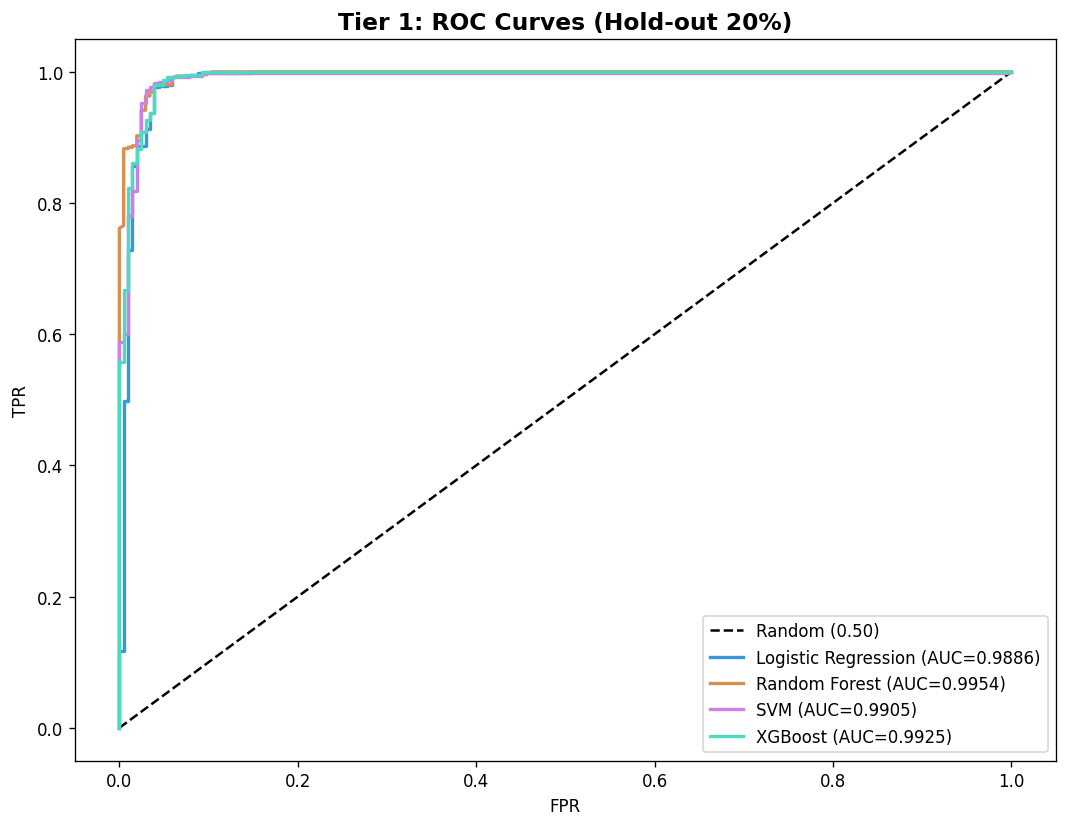

In [11]:
# VIZ 4: ROC Curves (hold-out)
X_tr,X_te,y_tr,y_te = train_test_split(X_full,y_full,test_size=0.2,stratify=y_full,random_state=SEED)
fig, ax = plt.subplots(figsize=(9,7))
ax.plot([0,1],[0,1],'k--',label='Random (0.50)')
for name,color in zip(MODEL_NAMES,MODEL_COLORS):
    models[name].fit(X_tr,y_tr)
    y_prob=models[name].predict_proba(X_te)[:,1]
    fpr,tpr,_=roc_curve(y_te,y_prob)
    ax.plot(fpr,tpr,color=color,lw=2,label=f'{name} (AUC={roc_auc_score(y_te,y_prob):.4f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Tier 1: ROC Curves (Hold-out 20%)',fontsize=14,fontweight='bold')
ax.legend(loc='lower right',fontsize=10)
plt.tight_layout()
plt.savefig('t1_plot_04_roc_curves.png',bbox_inches='tight'); plt.show()

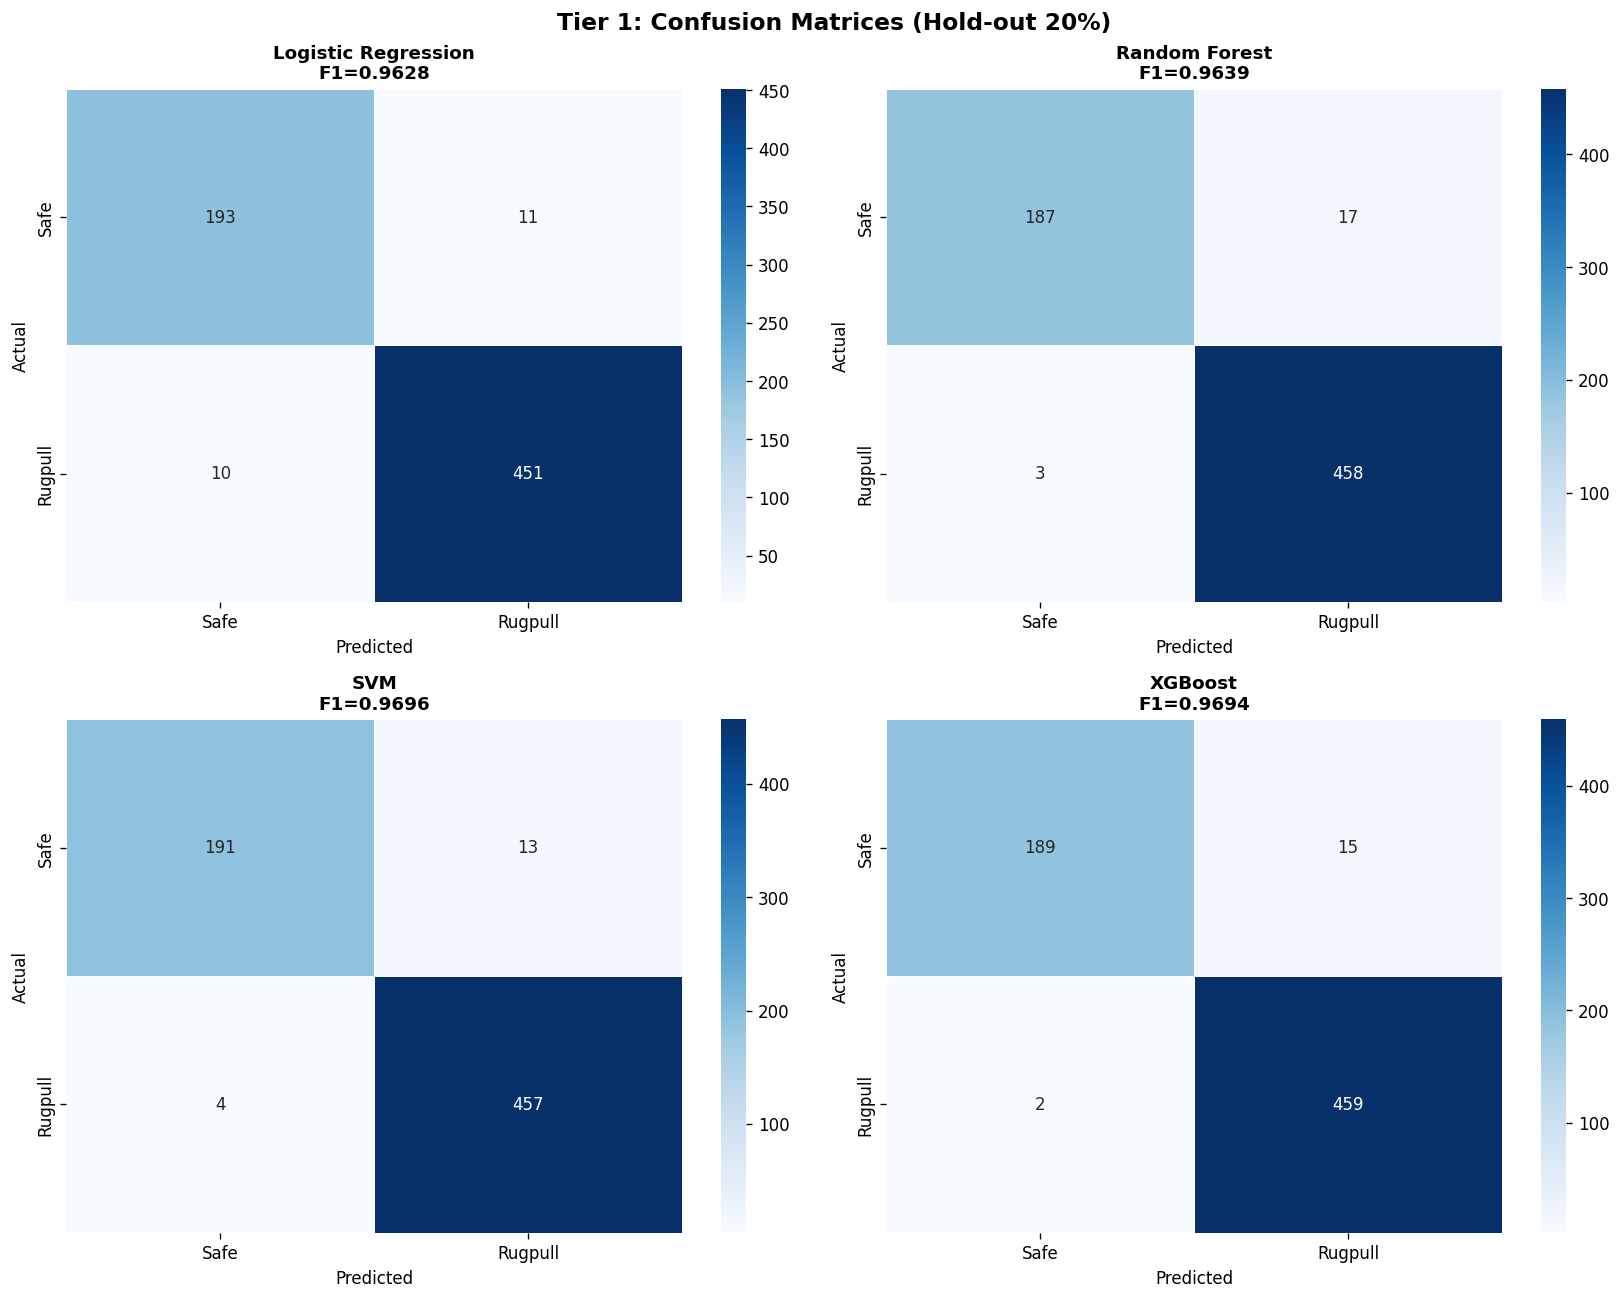

In [12]:
# VIZ 5: Confusion Matrices — all 4 models
fig, axes = plt.subplots(2,2,figsize=(14,11))
fig.suptitle('Tier 1: Confusion Matrices (Hold-out 20%)',fontsize=14,fontweight='bold')
axes=axes.flatten()
for i,(name,color) in enumerate(zip(MODEL_NAMES,MODEL_COLORS)):
    y_pred=models[name].predict(X_te)
    cm=confusion_matrix(y_te,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i],
                xticklabels=['Safe','Rugpull'],yticklabels=['Safe','Rugpull'],linewidths=0.5)
    axes[i].set_title(f'{name}\nF1={f1_score(y_te,y_pred,average="macro"):.4f}',fontsize=11,fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('t1_plot_05_confusion.png',bbox_inches='tight'); plt.show()

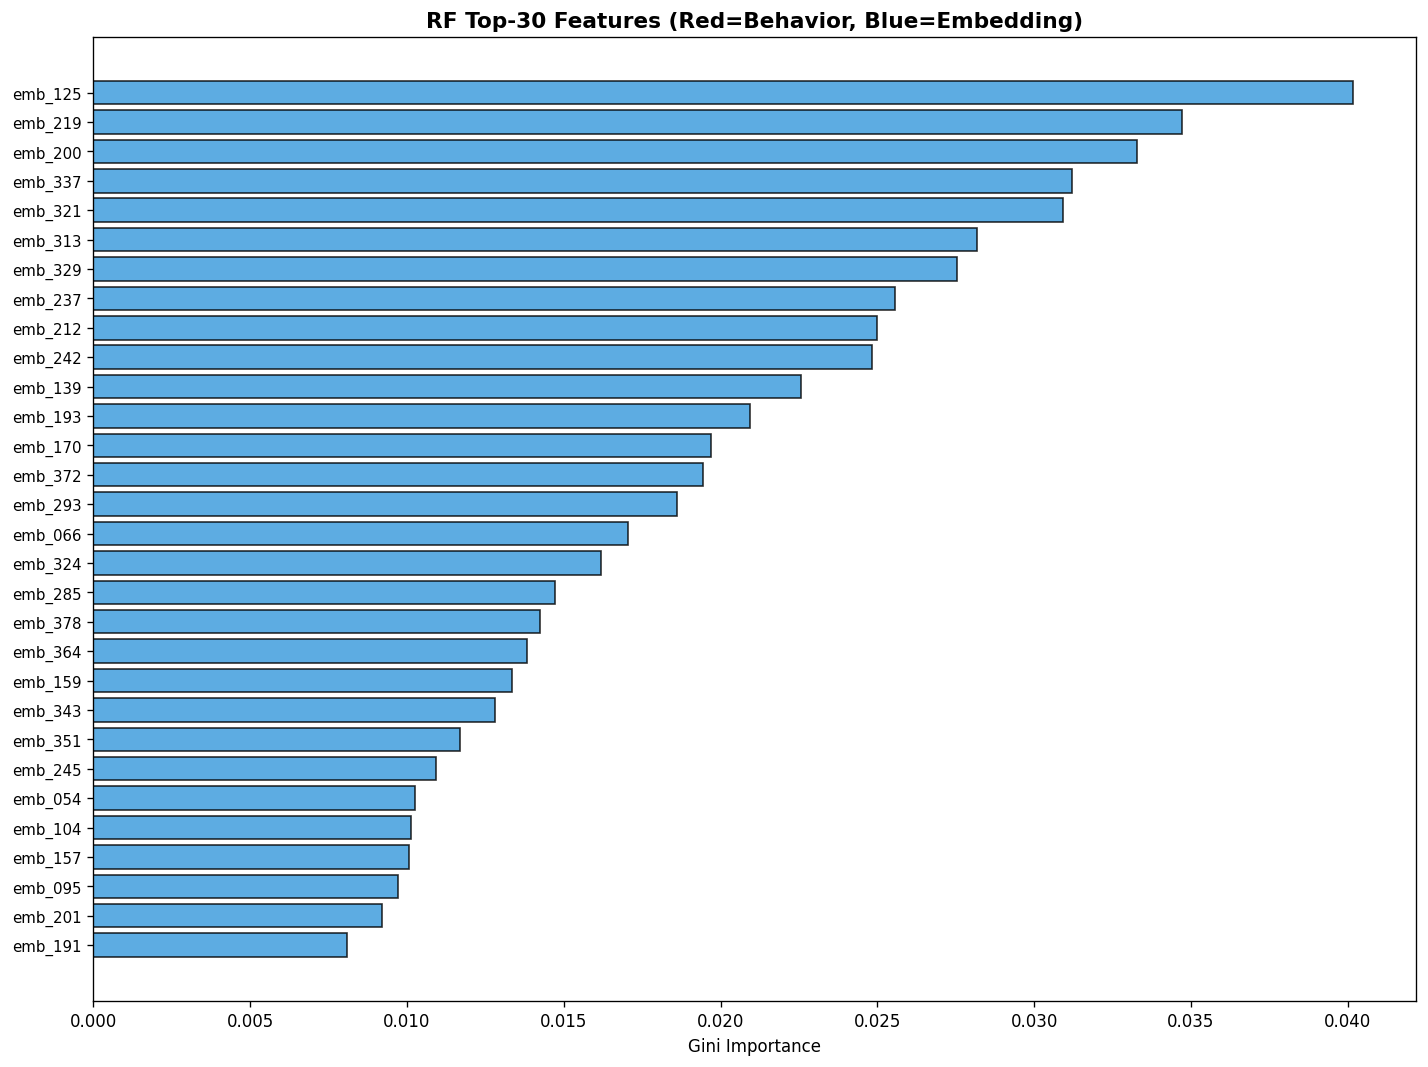

In [13]:
# VIZ 6: RF Feature Importance — top 30
rf=RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=SEED,n_jobs=-1)
rf.fit(X_tr,y_tr)
imp=rf.feature_importances_
top_idx=np.argsort(imp)[-30:][::-1]
top_names=[HYBRID_COLS[i] for i in top_idx]
top_vals=imp[top_idx]
fig,ax=plt.subplots(figsize=(12,9))
bar_c=['#e74c3c' if 'emb_' not in n else '#3498db' for n in top_names]
ax.barh(range(30),top_vals[::-1],color=bar_c[::-1],edgecolor='black',alpha=0.8)
ax.set_yticks(range(30)); ax.set_yticklabels(top_names[::-1],fontsize=9)
ax.set_xlabel('Gini Importance')
ax.set_title('RF Top-30 Features (Red=Behavior, Blue=Embedding)',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('t1_plot_06_rf_importance.png',bbox_inches='tight'); plt.show()

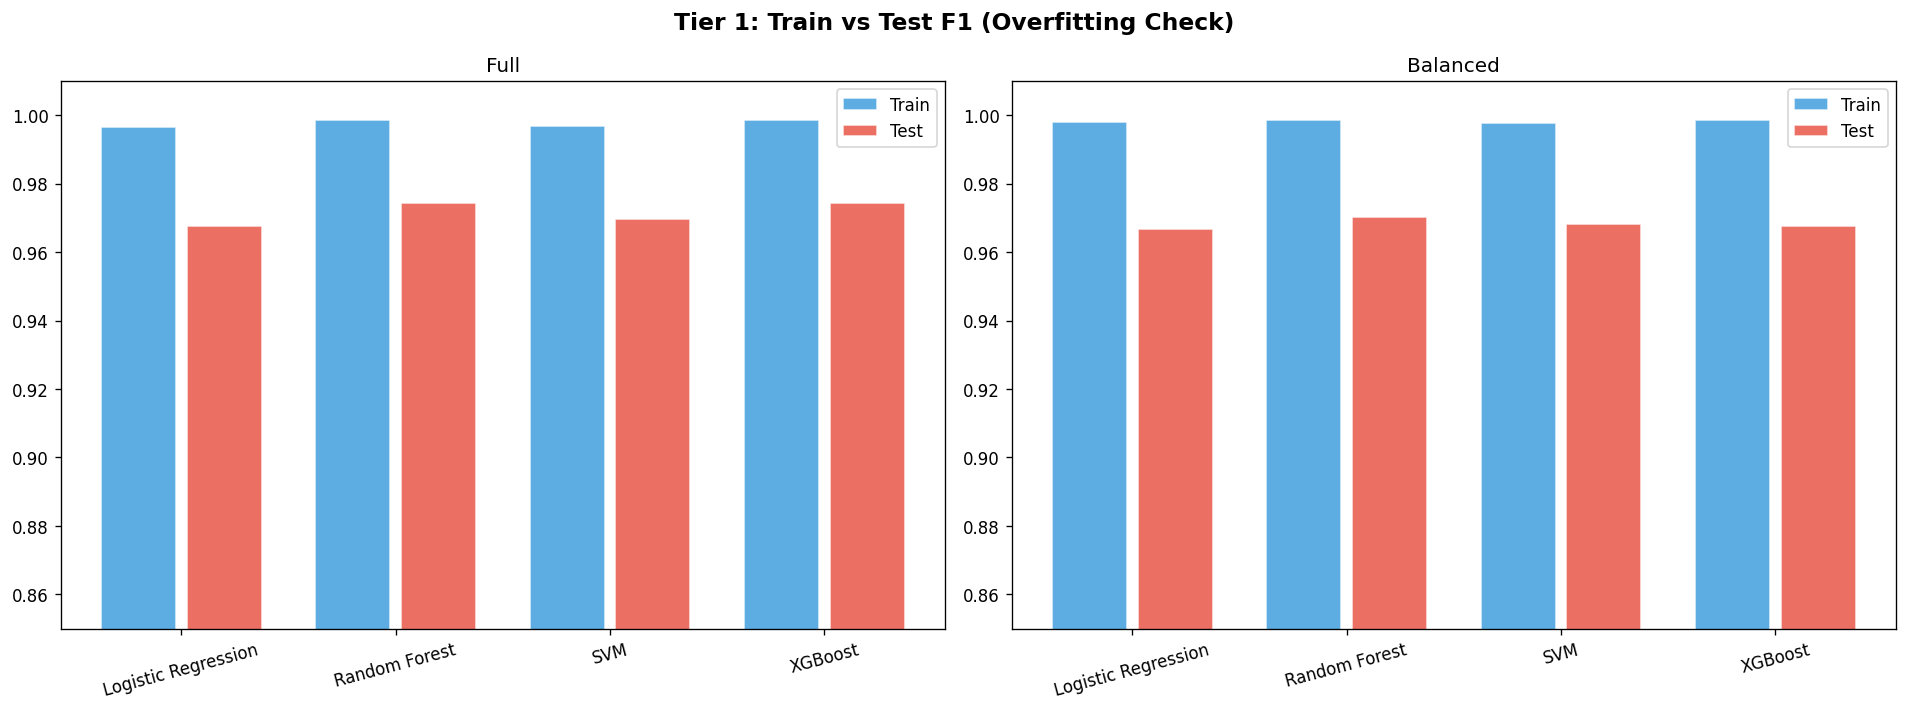

In [14]:
# VIZ 7: Train vs Test F1 (overfitting check)
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Tier 1: Train vs Test F1 (Overfitting Check)',fontsize=14,fontweight='bold')
for ax,res,title in [(axes[0],results_full,'Full'),(axes[1],results_bal,'Balanced')]:
    tr=[res[m]['train_f1_macro'].mean() for m in MODEL_NAMES]
    te=[res[m]['test_f1_macro'].mean()  for m in MODEL_NAMES]
    x=np.arange(len(MODEL_NAMES))
    ax.bar(x-0.2,tr,0.35,label='Train',color='#3498db',alpha=0.8,edgecolor='white')
    ax.bar(x+0.2,te,0.35,label='Test', color='#e74c3c',alpha=0.8,edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES,rotation=15)
    ax.set_ylim(0.85,1.01); ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig('t1_plot_07_train_vs_test.png',bbox_inches='tight'); plt.show()

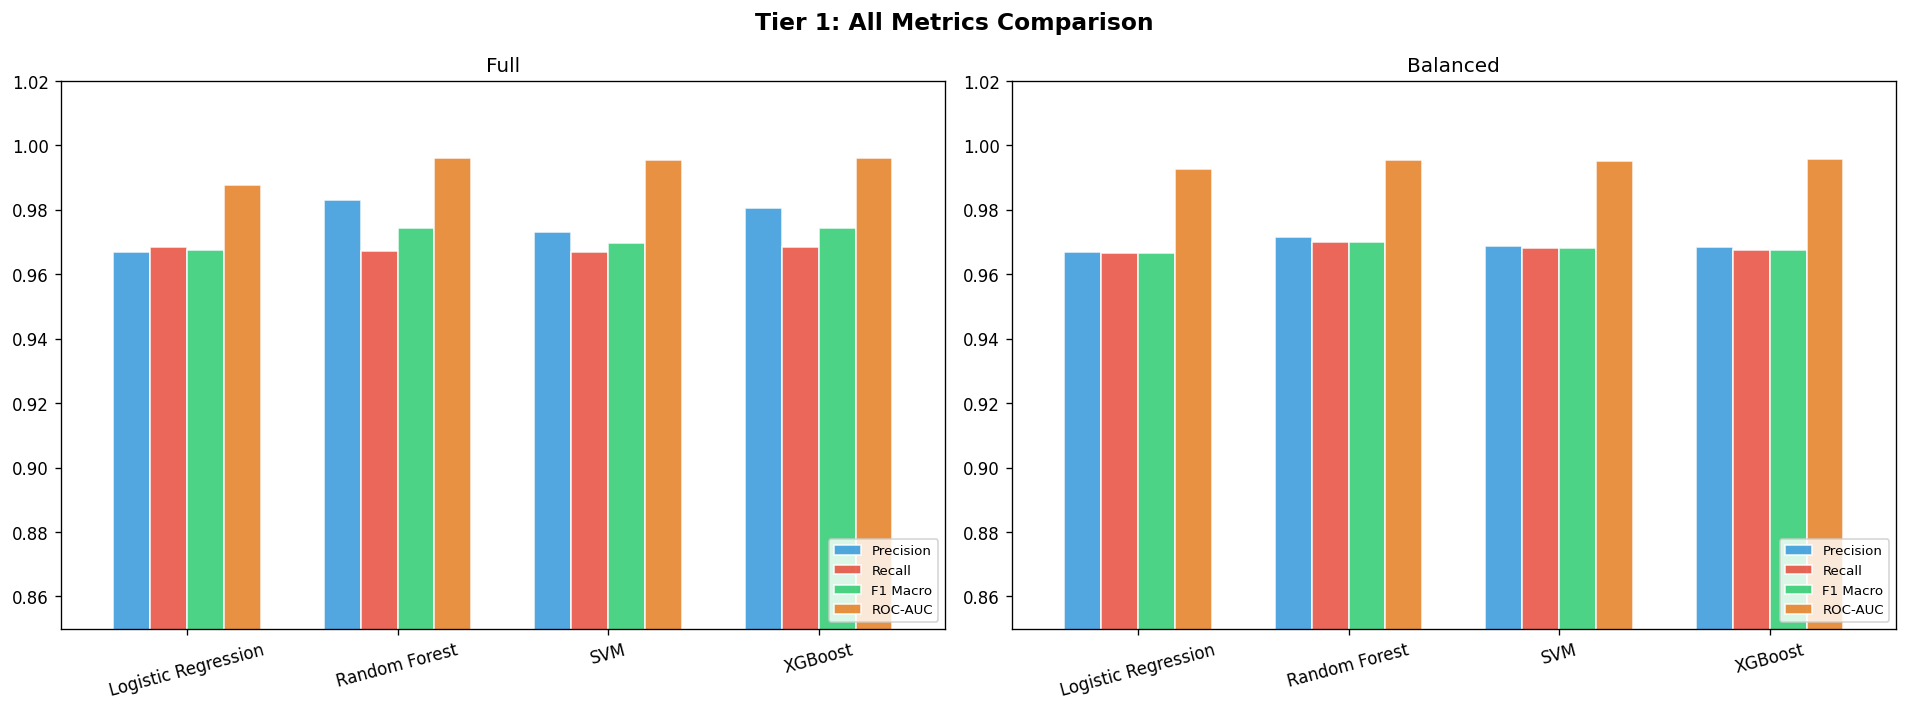

In [15]:
# VIZ 8: Multi-metric grouped bar
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Tier 1: All Metrics Comparison',fontsize=14,fontweight='bold')
metric_keys=['test_precision_macro','test_recall_macro','test_f1_macro','test_roc_auc']
metric_labels=['Precision','Recall','F1 Macro','ROC-AUC']
for ax,res,title in [(axes[0],results_full,'Full'),(axes[1],results_bal,'Balanced')]:
    data={name:[res[name][k].mean() for k in metric_keys] for name in MODEL_NAMES}
    pd.DataFrame(data,index=metric_labels).T.plot(kind='bar',ax=ax,
        color=['#3498db','#e74c3c','#2ecc71','#e67e22'],edgecolor='white',alpha=0.85,width=0.7)
    ax.set_ylim(0.85,1.02); ax.set_title(title); ax.set_xticklabels(MODEL_NAMES,rotation=15)
    ax.legend(metric_labels,loc='lower right',fontsize=8)
plt.tight_layout()
plt.savefig('t1_plot_08_all_metrics.png',bbox_inches='tight'); plt.show()

In [16]:
# Save JSON for combined notebook
tier1_raw={}
for name in MODEL_NAMES:
    tier1_raw[name]={
        'full_f1_mean':  float(results_full[name]['test_f1_macro'].mean()),
        'full_f1_std':   float(results_full[name]['test_f1_macro'].std()),
        'full_auc_mean': float(results_full[name]['test_roc_auc'].mean()),
        'bal_f1_mean':   float(results_bal[name]['test_f1_macro'].mean()),
        'bal_auc_mean':  float(results_bal[name]['test_roc_auc'].mean()),
    }
with open('tier1_raw_results.json','w') as f: json.dump(tier1_raw,f,indent=2)
print('Saved: tier1_results.csv | tier1_raw_results.json')
print('=== TIER 1 COMPLETE ===')

Saved: tier1_results.csv | tier1_raw_results.json
=== TIER 1 COMPLETE ===
